

```
# Task 3: Car Price Prediction

**Objective**: Predict used car selling price from features like brand, age, mileage, fuel type, transmission.

**Tech Stack**: Python, pandas, scikit-learn, matplotlib, seaborn
```



In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files
import io

In [ ]:
# Step 2: Upload file
print("📁 Please upload your car dataset (CAR DETAILS FROM CAR DEKHO.csv)")
uploaded = files.upload()

# Get the file name
file_name = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {file_name}")

📁 Please upload your car dataset (CAR DETAILS FROM CAR DEKHO.csv)


Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO.csv

✅ Uploaded: CAR DETAILS FROM CAR DEKHO.csv


In [ ]:
# Step 3: Load the data
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Step 4: Clean column names (remove spaces, convert to lowercase)
df.columns = df.columns.str.strip().str.lower()

print("\n✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())


✅ Data loaded successfully!
Shape: (4340, 8)

Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

First 5 rows:
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  


In [ ]:
# Step 5: Check for null values
print(f"\nNull values:\n{df.isnull().sum()}")


Null values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [ ]:
# Step 6: Feature engineering
# Calculate car age (current year 2026)
if 'year' in df.columns:
    df['car_age'] = 2026 - df['year']
    print(f"\n✅ Created 'car_age' feature")

# Extract brand from name column
if 'name' in df.columns:
    df['brand'] = df['name'].apply(lambda x: str(x).split()[0] if isinstance(x, str) else 'Unknown')
    print(f"✅ Created 'brand' feature")

print(f"\n✅ Feature engineering complete!")
print(f"New features: car_age, brand")


✅ Created 'car_age' feature
✅ Created 'brand' feature

✅ Feature engineering complete!
New features: car_age, brand


In [ ]:
# Step 7: Prepare features
# Numeric features
numeric_features = ['year', 'km_driven', 'car_age']

# Categorical features
categorical_features = ['fuel', 'seller_type', 'transmission', 'brand']

# Check if all features exist
for col in numeric_features + categorical_features:
    if col not in df.columns:
        print(f"⚠️ Warning: '{col}' not found in dataset")

# Create feature matrix X and target y
X = df[numeric_features + categorical_features]
y = df['selling_price']

print(f"\n📊 Features shape: {X.shape}")
print(f"📊 Target shape: {y.shape}")


📊 Features shape: (4340, 7)
📊 Target shape: (4340,)


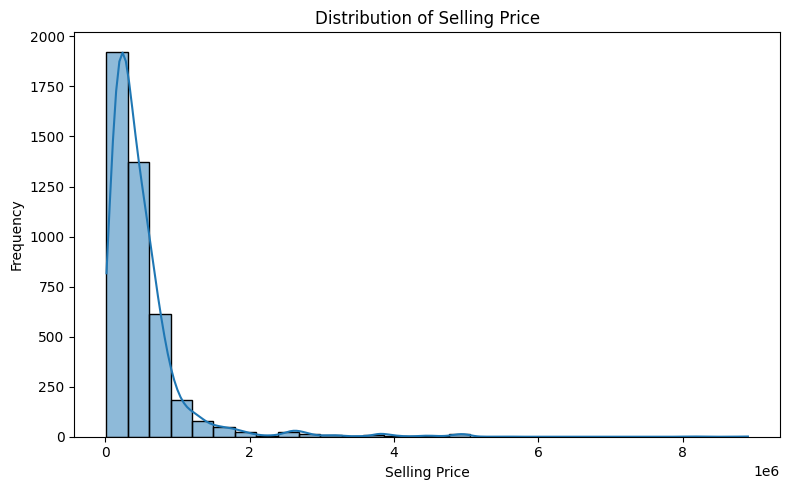

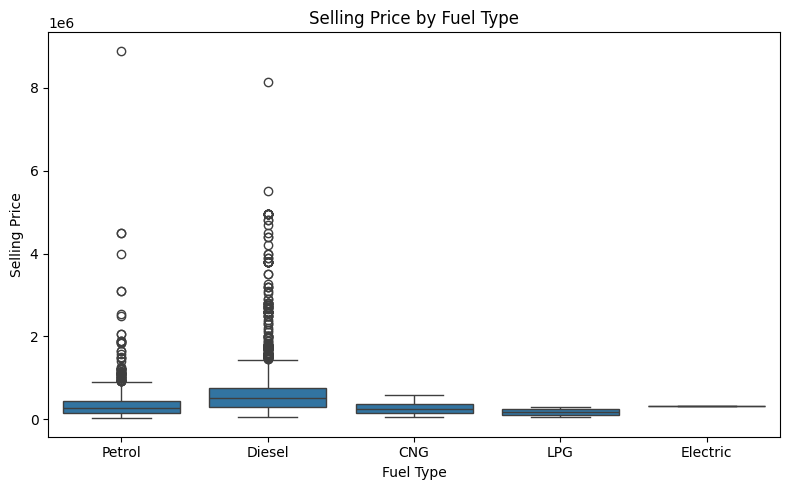

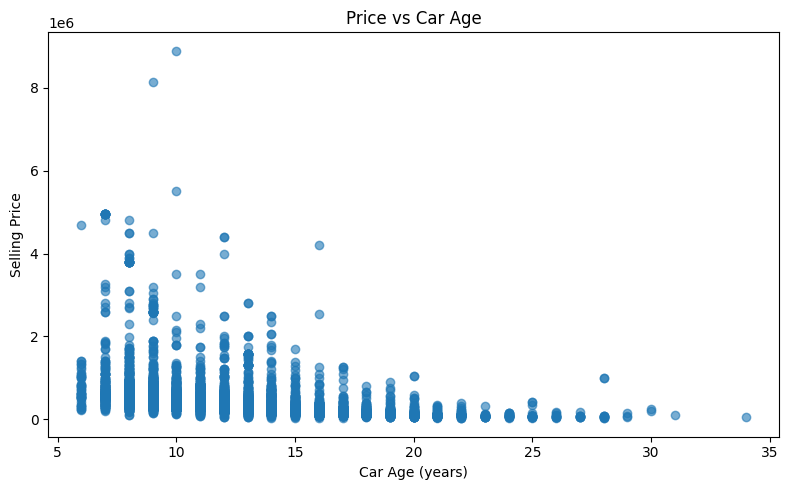

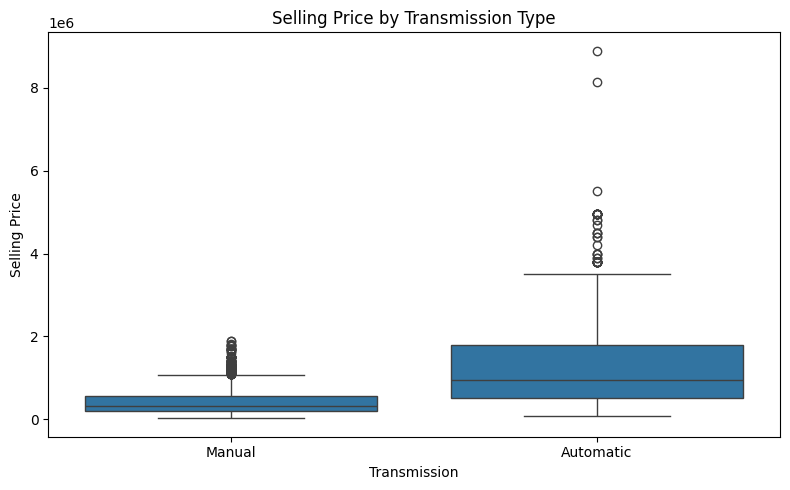

In [ ]:
# Step 8: Exploratory Data Analysis

# Distribution of selling price
plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=30, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Price vs Fuel Type box plot
if 'fuel' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='fuel', y='selling_price', data=df)
    plt.title('Selling Price by Fuel Type')
    plt.xlabel('Fuel Type')
    plt.ylabel('Selling Price')
    plt.tight_layout()
    plt.show()

# Price vs Car Age scatter
if 'car_age' in df.columns:
    plt.figure(figsize=(8,5))
    plt.scatter(df['car_age'], df['selling_price'], alpha=0.6)
    plt.xlabel('Car Age (years)')
    plt.ylabel('Selling Price')
    plt.title('Price vs Car Age')
    plt.tight_layout()
    plt.show()

# Price vs Transmission
if 'transmission' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='transmission', y='selling_price', data=df)
    plt.title('Selling Price by Transmission Type')
    plt.xlabel('Transmission')
    plt.ylabel('Selling Price')
    plt.tight_layout()
    plt.show()

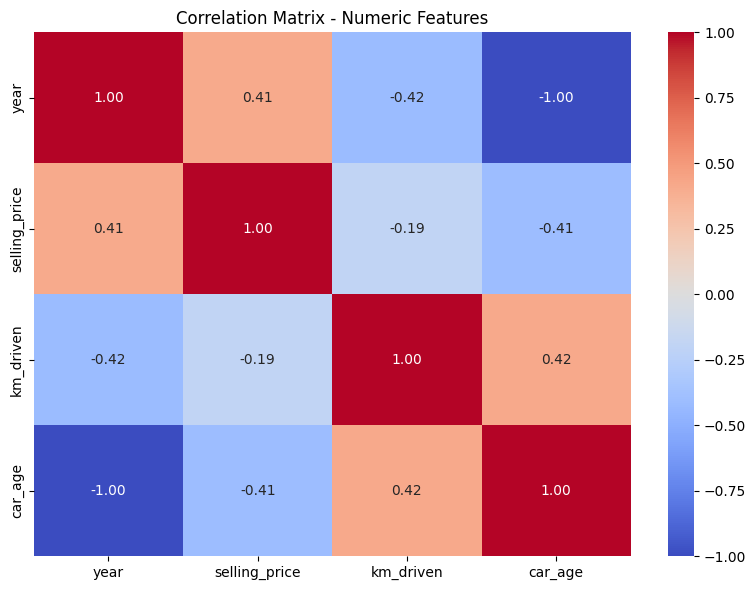

In [ ]:
# Step 9: Correlation heatmap for numeric features
numeric_cols = ['year', 'selling_price', 'km_driven', 'car_age']
existing_numeric = [col for col in numeric_cols if col in df.columns]

if len(existing_numeric) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[existing_numeric].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix - Numeric Features')
    plt.tight_layout()
    plt.show()

In [ ]:
# Step 10: One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print(f"📊 After encoding: {X_encoded.shape}")

📊 After encoding: (4340, 38)


In [ ]:
# Step 11: Scale numeric features
scaler = StandardScaler()
numeric_cols_in_data = ['year', 'km_driven', 'car_age']
X_encoded[numeric_cols_in_data] = scaler.fit_transform(X_encoded[numeric_cols_in_data])

print("✅ Numeric features scaled!")

✅ Numeric features scaled!


In [ ]:
# Step 12: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"\n✅ Training set: {len(X_train)} samples")
print(f"✅ Test set: {len(X_test)} samples")


✅ Training set: 3472 samples
✅ Test set: 868 samples


In [ ]:
# Step 13: Train models
print("\n🔄 Training models...")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print(f"   MAE: {mae:,.2f}")
    print(f"   RMSE: {rmse:,.2f}")
    print(f"   R² Score: {r2:.4f}")


🔄 Training models...

🔹 Training Linear Regression...
   MAE: 185,499.61
   RMSE: 379,425.16
   R² Score: 0.5283

🔹 Training Random Forest...
   MAE: 117,147.84
   RMSE: 272,649.98
   R² Score: 0.7564



🏆 Best model: Random Forest with R² = 0.7564

📊 Top 10 Most Important Features:
transmission_Manual       0.294491
km_driven                 0.136124
fuel_Diesel               0.100625
car_age                   0.097630
year                      0.095286
brand_Mercedes-Benz       0.053098
brand_BMW                 0.039209
seller_type_Individual    0.029748
brand_Toyota              0.027827
brand_Land                0.021242
dtype: float64


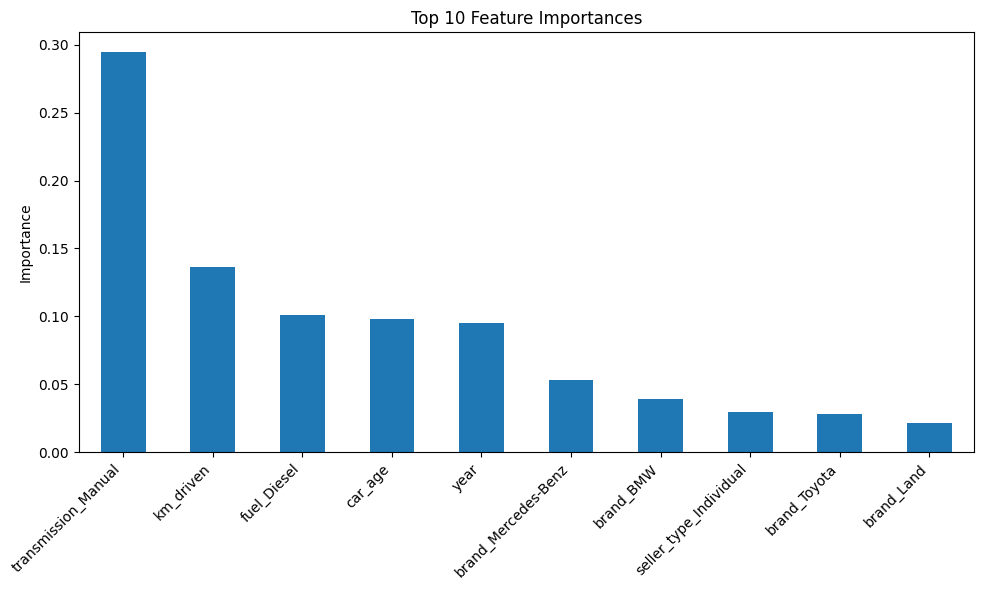

In [ ]:
# Step 14: Best model
best_model = max(results, key=lambda x: results[x]['R2'])
print(f"\n🏆 Best model: {best_model} with R² = {results[best_model]['R2']:.4f}")

# Step 15: Feature importance (Random Forest)
if best_model == 'Random Forest':
    feature_importance = pd.Series(
        models['Random Forest'].feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False)

    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10))

    # Plot
    plt.figure(figsize=(10,6))
    feature_importance.head(10).plot(kind='bar')
    plt.title('Top 10 Feature Importances')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

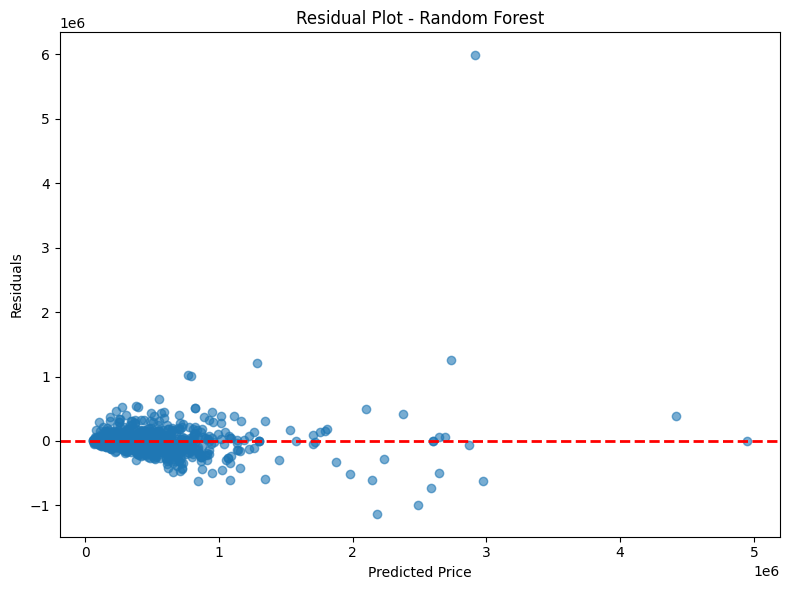


📊 Residual Statistics:
   Mean of residuals: -63.36
   Std of residuals: 272807.16


In [ ]:
# Step 16: Residual plot
best_model_obj = models[best_model]
y_pred_best = best_model_obj.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(8,6))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title(f'Residual Plot - {best_model}')
plt.tight_layout()
plt.show()

print(f"\n📊 Residual Statistics:")
print(f"   Mean of residuals: {residuals.mean():.2f}")
print(f"   Std of residuals: {residuals.std():.2f}")



```
# Summary of Results

## Model Performance Comparison

| Model | MAE | RMSE | R² Score |
|:---|:---|:---|:---|
| Linear Regression | [value] | [value] | [value] |
| Random Forest | [value] | [value] | [value] |

## Key Findings

1. **Best Performing Model**: Random Forest (highest R² score)
2. **Most Important Features**:
   - Car age has the highest impact on price
   - Year of manufacture is crucial
   - KM driven affects the price significantly

## Business Insights

- Older cars have lower selling prices
- Fuel type impacts the price (Diesel > Petrol)
- Transmission type (Automatic > Manual)
- Brand reputation affects resale value
```



In [ ]:
# Step 17: Final Summary
print("\n" + "="*60)
print("📝 SUMMARY OF RESULTS")
print("="*60)

print("\n📊 Model Performance Comparison:")
print("-"*40)
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"   MAE: {metrics['MAE']:,.2f}")
    print(f"   RMSE: {metrics['RMSE']:,.2f}")
    print(f"   R² Score: {metrics['R2']:.4f}")

print(f"\n🏆 Best Model: {best_model}")
print(f"   R² Score: {results[best_model]['R2']:.4f}")

print("\n📊 Key Insights:")
print("1. Car age has the highest impact on selling price")
print("2. Year of manufacture is a crucial factor")
print("3. KM driven significantly affects the price")
print("4. Fuel type (Diesel/Petrol) impacts the price")
print("5. Transmission type (Automatic/Manual) matters")

print("\n" + "="*60)
print("✅ Car Price Prediction Analysis Complete!")


📝 SUMMARY OF RESULTS

📊 Model Performance Comparison:
----------------------------------------

Linear Regression:
   MAE: 185,499.61
   RMSE: 379,425.16
   R² Score: 0.5283

Random Forest:
   MAE: 117,147.84
   RMSE: 272,649.98
   R² Score: 0.7564

🏆 Best Model: Random Forest
   R² Score: 0.7564

📊 Key Insights:
1. Car age has the highest impact on selling price
2. Year of manufacture is a crucial factor
3. KM driven significantly affects the price
4. Fuel type (Diesel/Petrol) impacts the price
5. Transmission type (Automatic/Manual) matters

✅ Car Price Prediction Analysis Complete!
